# Análise de Performance de Produção Pós Retrofit

- **Situação:** No ambiente industrial, as máquinas passam regularmente por manutenções corretivas, preventivas e preditivas. Além disso, pode ocorrer o *retrofit*, que é a atualização tecnológica de máquinas antigas por meio da troca de partes ultrapassadas (sejam elétricas, eletrônicas ou hidráulicas) por soluções modernas, preservando a estrutura física original. Essa prática visa aumentar a produtividade, segurança e eficiência,  com investimento abaixo da compra de uma máquina nova.
- Após o *retrofit* de uma máquina injetora, o objetivo desta análise é verificar se ela está operando dentro do tempo de ciclo esperado.
- **Tempo de ciclo esperado:** 30 segundos (120 pçs/hora)
- **Objetivo da Análise:** Avaliar a estabilidade e desempenho do processo após o retrofit, utilizando indicadores estatísticos e de produtividade.

In [38]:
#Bibliotecas
import numpy as np
import matplotlib.pyplot as plt

## Gerar Dados com Numpy
- Gerar dados simulados de tempo de ciclo com valores aleatórios reprodutíveis;
- **Variação:** Entre 20 e 45 segundos;
- **Amostra:** A média de tempo de ciclo diário dos últimos 30 dias

In [44]:
#Gerador de números aleatórios com semente fixa (reprodutível)
rng = np.random.default_rng(seed=42)
dados_tempo_ciclo = rng.integers(low=20, high=46, size=30) #high é exclusivo → gera valores de 20 até 45
print(dados_tempo_ciclo) 

[22 40 37 31 31 42 22 38 25 22 33 45 39 39 38 40 33 23 41 31 33 29 24 44
 40 36 30 41 34 31]


## Produtividade
- Analisar média e mediana do tempo de ciclo em relação ao tempo esperado;
- Calcular a produtividade real (pçs/h) e comparar com a produtividade esperada;
- Avaliar a variação de produtividade (%).
- Verificar conformidade dos ciclos em relação à meta (dias acima do esperado).

In [5]:
#Estatísticas
media = np.mean(dados_tempo_ciclo)
mediana = np.median(dados_tempo_ciclo)
desvio_padrao = np.std(dados_tempo_ciclo)
tempo_esperado = 30

In [13]:
#1. Calcular produtividade
produtividade_real = 3600 / media
produtividade_esperada = 3600 / tempo_esperado
variacao_produtividade = ((produtividade_real - produtividade_esperada) / produtividade_esperada) * 100

print(f"=== ANÁLISE PÓS-RETROFIT ===")
print(f"Tempo de ciclo médio: {media:.1f} s")
print(f"Tempo de ciclo mediano: {mediana:.1f} s")
print(f"Tempo esperado: {tempo_esperado} s")
print(f"Diferença de ciclo: {media - tempo_esperado:+.1f} s ({((media/tempo_esperado)-1)*100:+.1f}%)")

print(f"\nProdutividade real: {produtividade_real:.0f} pçs/h")
print(f"Produtividade esperada: {produtividade_esperada:.0f} pçs/h")
print(f"Variação de produtividade: {variacao_produtividade:+.1f}%")

=== ANÁLISE PÓS-RETROFIT ===
Tempo de ciclo médio: 33.8 s
Tempo de ciclo mediano: 33.5 s
Tempo esperado: 30 s
Diferença de ciclo: +3.8 s (+12.7%)

Produtividade real: 107 pçs/h
Produtividade esperada: 120 pçs/h
Variação de produtividade: -11.2%


In [46]:
#2. Análise de conformidade
#Validar se o problema é pontual ou frequente
dias_acima_limite = np.sum(dados_tempo_ciclo > tempo_esperado)
percentual_acima = (dias_acima_limite / 30) * 100
print(f"\nDias acima do esperado: {dias_acima_limite}/30 ({percentual_acima:.0f}%)")


Dias acima do esperado: 22/30 (73%)


## Variabilidade do Processo
- Calcular o coeficiente de variação e classificar;
- Identificar outliers (anomalias).

In [17]:
# 3. Coeficiente de variação (CV)
# < 5% → processo estável | 5–10% → atenção | > 10% → instável

cv = (desvio_padrao / media) * 100

if cv < 5:
    classificacao = "Estável"
elif cv <= 10:
    classificacao = "Atenção"
else:
    classificacao = "Instável"

print(f"Coeficiente de variação: {cv:.1f}% ({classificacao})")

Coeficiente de variação: 20.2% (Instável)


In [19]:
# 4. Identificar anomalias (2 desvios padrão)
anomalias = np.where((dados_tempo_ciclo > media + 2 * desvio_padrao) | 
                     (dados_tempo_ciclo < media - 2 * desvio_padrao))

if len(anomalias[0]) > 0:
    print(f"\n⚠️ Anomalias detectadas: {dados_tempo_ciclo[anomalias]}")
else:
    print(f"\n✓ Nenhuma anomalia significativa detectada")


✓ Nenhuma anomalia significativa detectada


## Visualização Gráfica
- Calcular os limites de controle (UCL e LCL) com base no CEP;
- Plotar gráfico de controle para visualizar a variação e estabilidade do processo.

In [21]:
# 5. CEP (Controle Estatístico do Processo)
# ±3σ → limites de controle (UCL/LCL)

ucl = media + 3 * desvio_padrao
lcl = media - 3 * desvio_padrao

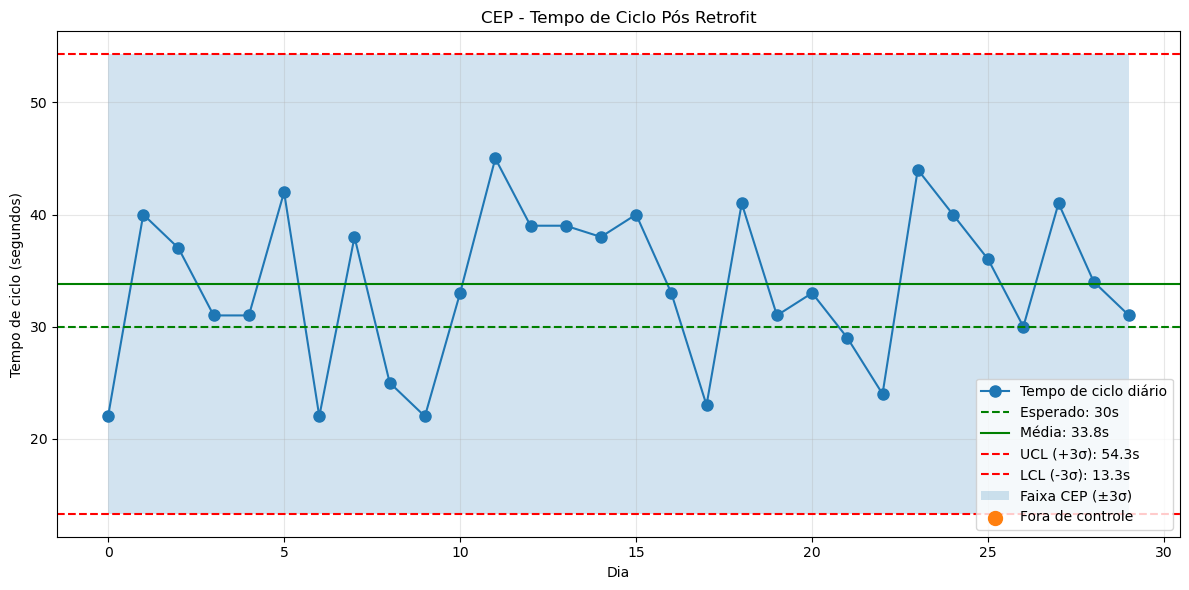

In [31]:
# 6. Visualização

plt.figure(figsize=(12, 6))

plt.plot(dados_tempo_ciclo, 'o-', label='Tempo de ciclo diário', markersize=8)

# Linhas principais
plt.axhline(y=tempo_esperado, linestyle='--', label=f'Esperado: {tempo_esperado}s', color='green')
plt.axhline(y=media, linestyle='-', label=f'Média: {media:.1f}s', color='green')

# Limites estatísticos
plt.axhline(y=ucl, linestyle='--', label=f'UCL (+3σ): {ucl:.1f}s', color='red')
plt.axhline(y=lcl, linestyle='--', label=f'LCL (-3σ): {lcl:.1f}s', color='red')

# Faixa de controle estatístico
plt.fill_between(range(30), lcl, ucl, alpha=0.2, label='Faixa CEP (±3σ)')

# Destacar pontos fora de controle
out_of_control = (dados_tempo_ciclo > ucl) | (dados_tempo_ciclo < lcl)
plt.scatter(np.where(out_of_control), dados_tempo_ciclo[out_of_control], s=100, label='Fora de controle')

# Labels
plt.xlabel('Dia')
plt.ylabel('Tempo de ciclo (segundos)')
plt.title('CEP - Tempo de Ciclo Pós Retrofit')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusão
<p>
Após o retrofit da injetora, os dados coletados ao longo de 30 dias indicam que:

- O tempo médio de ciclo ficou em **33,8 s**, **3,8 s** acima da meta de 30 segundos.
- Isso representa uma perda de produtividade de aproximadamente **11,2%**, com produção média de **107** peças/hora, contra as 120 esperadas peças/hora.
- Dos 30 dias analisados, **22 dias (73%)** performaram acima do estabelecido, indicando recorrência do desvio.
- O coeficiente de variação indica um processo com **alta variabilidade (instável)**.
- Não foram identificadas anomalias relevantes (pontos fora de controle), sugerindo ausência de causas especiais.
- No gráfico de controle, é observado variações consistentes ao longo do período, reforçando que o processo apresenta **variabilidade contínua**, e não desvios pontuais.
- O processo encontra-se estável do ponto de vista estatístico (sem causas especiais), porém desalinhado com a meta de desempenho, indicando necessidade de ajustes no processo para redução do tempo de ciclo.

# Ferramentas Utilizadas
**Criado por:** Yara de Oliveira Rufino

In [15]:
import sys
import numpy as np
import matplotlib
import notebook

print("===== AMBIENTE =====")
print("🐍 Python:", sys.version.split()[0])
print("📓 Jupyter Notebook:", notebook.__version__)
print("\n")
print("===== BIBLIOTECAS =====")
print("🧊 Numpy: ", np.__version__)
print("📊 Matplotlib:", matplotlib.__version__)

===== AMBIENTE =====
🐍 Python: 3.12.7
📓 Jupyter Notebook: 7.2.2


===== BIBLIOTECAS =====
🧊 Numpy:  1.26.4
📊 Matplotlib: 3.9.2
